
# Deep Neural Networks
## Image classification with a simple neural network
This notebook will guide you through the implementation of neural networks using a specialised library called Keras. Keras is a deep learning library known for its accessibility. It has recently been integrated into the Google backend framework, named TensorFlow, which is more technical and focused on performance. To run this notebook, you need to have Tensorflow and Keras installed. You can find instructions here: https://keras.io/getting_started/.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.17.0



### Prepare the data
For your first experiment with neural networks, we propose to use the example of clothing image classification, using the Fashion MNIST dataset (https://github.com/zalandoresearch/fashion-mnist). This dataset can be loaded directly from TensorFlow. It contains 70,000 grayscale images from 10 categories. The images show individual articles of clothing at low resolution (28x28 pixels). We will use 60,000 images to train the network and 10,000 images to evaluate how accurately the network learned to classify images. 

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape)
print(X_test.shape)
print(y_train) # labels are class indices (0-9) that corresponds to the following class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

(60000, 28, 28)
(10000, 28, 28)
[9 0 0 ... 3 0 5]


Images must be preprocessed before feeding them to a NN. If you inspect the raw values of the images, you will see that the pixel values fall in the range of 0 to 255. We need to scale these values to a range of 0 to 1 before feeding them to the neural network model. To do this, we divide the values by 255:

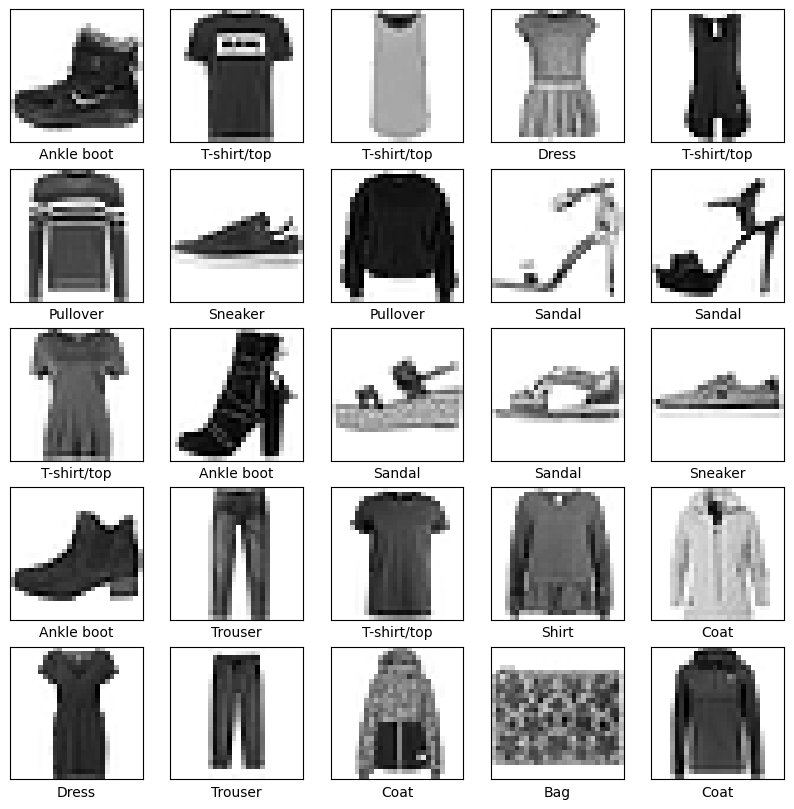

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

### Build the model
We now need to build the model, that is to say to define the architecture of the neural network and to assemble the different building blocks. Keras gives several ways to do so, but the most simple one is to use a Sequential model. This model represents a linear stack of layers, that we will define one by one with the Keras API. For now, let's start with a simple architecture made up with three layers:
- An input layer that transforms the images from a 2d-array (28 x 28 pixels), to a 1d-array of 28 * 28 = 784 pixels (we "flatten" the image).
- A hidden layer of 128 neurons and ReLU activation functions.
- An output layer of 10 neurons (as there are 10 classes).

You can find more explanation about the use of Sequential models in the Keras documentation: https://keras.io/guides/sequential_model/

In [4]:
model = tf.keras.models.Sequential(name="simple_nn")
model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Before being able to train the model, we need to set few more things:
- An optimizer: this is the method that applies the gradient descent with all the optimization tricks (momentum, adaptative learning rate, etc.).
- A loss function: the function we want to minimize to "steer" the model in the right direction.
- Metrics: used to monitor the training and testing steps. The following example uses accuracy, the fraction of the images that are correctly classified.
  
In Keras, all this is specified with the `compile` method:

In [5]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

*Note: the `from_logits=True` allows to specify that the output of the network is not a probability distribution (like when using a softmax activation function). This is a valuable information for the cross-entropy loss function to be computed correctly. If the last layer of the network is a softmax layer, this option must be set to False.*

### Train the model
We are now ready to train the model. We set the batch size to 32 and the number of epochs to 30. We will also split the trainset to have a validation set to monitor the accuracy of the model on data it has never seen before. Finally, we can ask Keras to save the best model seen during training by using the callback `ModelCheckpoint`. This model is the one that minimizes the loss function on the validation set over all iterations.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
callbacks = [tf.keras.callbacks.ModelCheckpoint("ps4_firstNN.keras", save_best_only=True)] 
logs = model.fit(X_train, y_train, validation_data=(X_val,y_val), batch_size=32, epochs=20, callbacks=callbacks)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7675 - loss: 0.6644 - val_accuracy: 0.8406 - val_loss: 0.4549
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8572 - loss: 0.3958 - val_accuracy: 0.8587 - val_loss: 0.3959
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8743 - loss: 0.3553 - val_accuracy: 0.8747 - val_loss: 0.3476
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8829 - loss: 0.3181 - val_accuracy: 0.8693 - val_loss: 0.3653
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8903 - loss: 0.2995 - val_accuracy: 0.8725 - val_loss: 0.3551
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8948 - loss: 0.2855 - val_accuracy: 0.8773 - val_loss: 0.3433
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8970 - loss: 0.2708 - val_accuracy: 0.8748 - val_loss: 0.3535
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9028 - loss: 0.2589 - 

### Analysis of the result
To check that all has gone well during the training of a neural network, the first important thing to do is to monitor the loss during training. This can be done by looking at the history of the training stored in the `logs` object.

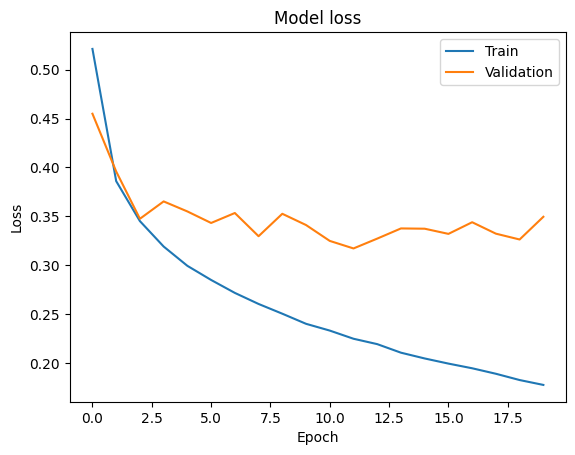

In [7]:
plt.plot(logs.history['loss']) 
plt.plot(logs.history['val_loss']) 
plt.title('Model loss') 
plt.ylabel('Loss') 
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='upper right') 
plt.show()

<span style="color:blue">What is your analysis of these curves? What can you conclude from them?</span>

### Evaluate the performance

The goal now is to evaluate the best model obtained during the learning phase on test data that has not been used before. Remember that it is important to evaluate the model on data that has not been used for any other purpose. As a result, we cannot use the validation data to establish whether our model is performing well.

Let's first have a look at the best model obtained during training:

In [8]:
best_epoch = np.argmin(logs.history['val_loss'])
best_val_loss = logs.history['val_loss'][best_epoch]
print(f"The best model have been obtained at epoch {best_epoch} with a loss equal to {best_val_loss}")
model = tf.keras.models.load_model("ps4_firstNN.keras")

The best model have been obtained at epoch 11 with a loss equal to 0.3172484040260315


Now, let's test our model on the test data, set aside at the beginning of the notebook. This can be done with the `evaluate`method:

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print('\nTest loss:', test_loss)
print('\nTest accuracy:', test_acc)

313/313 - 0s - 654us/step - accuracy: 0.8837 - loss: 0.3433

Test loss: 0.34331855177879333

Test accuracy: 0.8837000131607056


<span style="color:blue">What can you say about these results?</span>

We can also analyze the predictions of the model in a more qualitative way, by looking at some test examples and their corresponding predictions. To do so, we will add a softmax layer to convert the model's outputs to probabilities, which should be easier to interpret.

In [10]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(X_test)
print(f"Predictions (probabilities) of the first image: {predictions[0]}")
print(f"The class predicted is {np.argmax(predictions[0])}")
print(f"The true class is {y_test[0]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step
Predictions (probabilities) of the first image: [1.6740747e-08 1.8650624e-12 8.0986086e-11 2.5994196e-11 5.7398877e-09
 4.4545226e-04 3.3281695e-09 4.8706094e-03 5.4592624e-07 9.9468327e-01]
The class predicted is 9
The true class is 9


The two next functions are given to help you visualize the images side by side with the class probabilities predicted by the model.

In [11]:
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label], 100*np.max(predictions_array), class_names[true_label]), color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')


For example, for the first image of the test set:

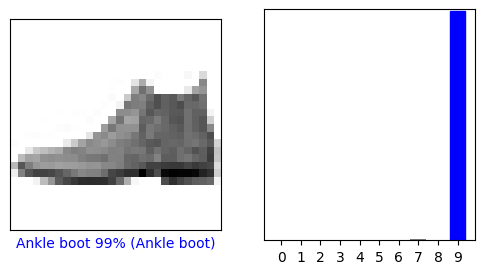

In [12]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

<span style="color:blue">Propose below a script to show similar plots for the 15 images of the test set, drawn at random.</span>

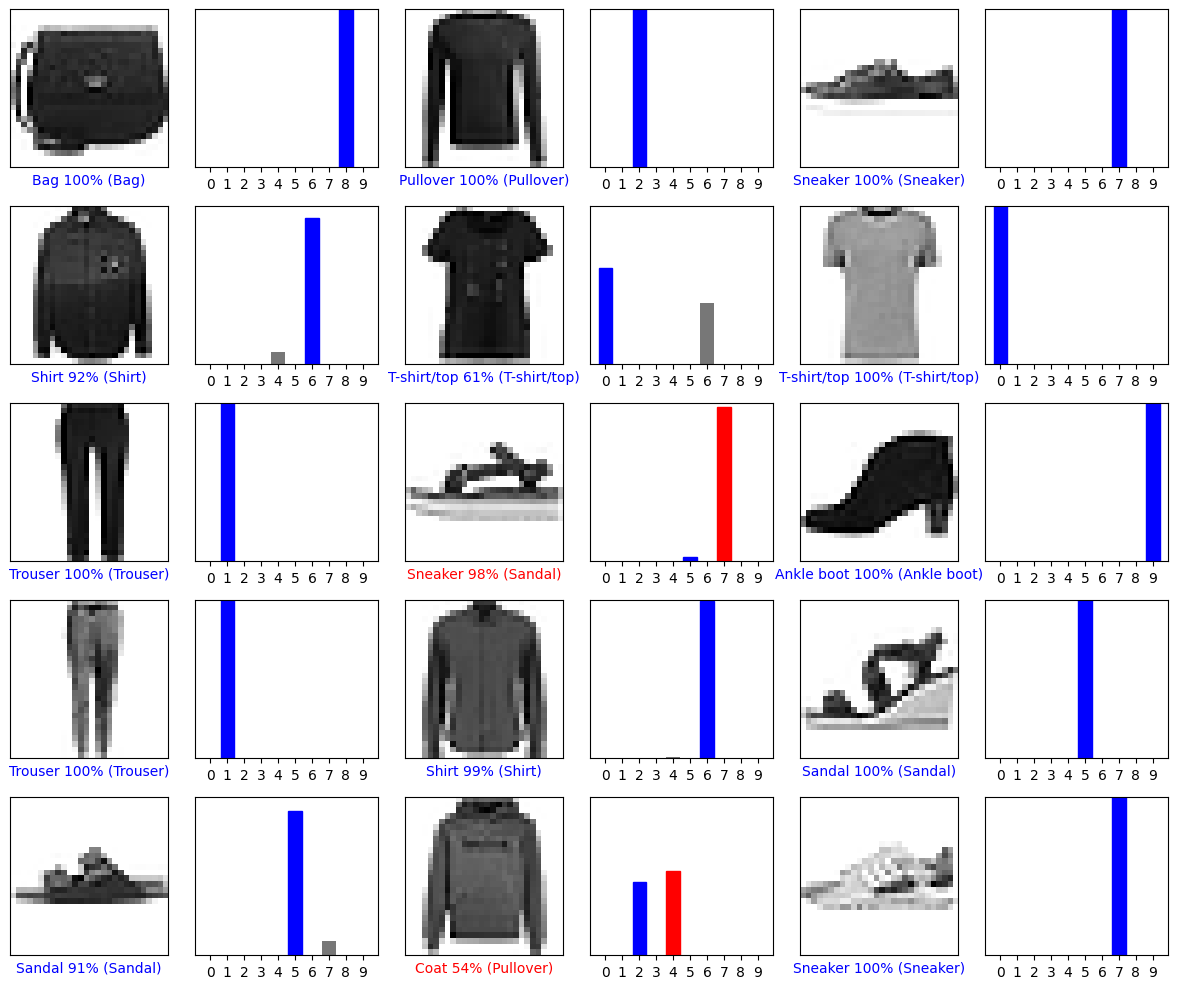

In [13]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    r = np.random.randint(0, X_test.shape[0])
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(r, predictions[r], y_test, X_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(r, predictions[r], y_test)
plt.tight_layout()
plt.show()

<span style="color:blue">Finally, as an exercice, propose your own neural network architecture to improve the performance on this dataset. You can change the number of layers, the number of neurons in each layer, the activation functions, the optimizer, etc. You can also use the validation set to tune the hyperparameters of your model.</span>